# 05 - Probabilistic Learning (Extension)

## What do losses and regularisation mean as beliefs?

Probabilistic language reads losses, penalties, and uncertainty as modelling assumptions.


This optional extension gives the earlier workshop pieces a probabilistic reading. Use it after Notebook 04 as a bridge from least squares and ridge regression to likelihoods, priors, evidence, MAP estimates, and posterior uncertainty.

The examples stay in the solar-panel tilt polynomial-regression setting. A fitted model leaves visible traces: residuals, unstable extrapolation, large or small coefficients, and regions where several curves remain plausible. This notebook asks what assumptions would make those traces reasonable.

We still use $\mathcal{D}$ for data, $\theta\in\Theta$ for parameters, $h_\theta\in\mathcal{H}$ for hypotheses, and $\mathcal{O}$ for the machinery that compares or summarises them.

**Translation key**

| Earlier object | Probabilistic reading | What to inspect |
|---|---|---|
| Residual loss | Gaussian likelihood | Which residuals are surprising for the chosen $\sigma$? |
| Ridge penalty | Gaussian prior | Which functions were plausible before seeing $\mathcal{D}$? |
| Ridge solution | MAP estimate | Which pressure dominates: fit or prior plausibility? |
| Model comparison | Evidence | Did the model class make this dataset typical? |
| Uncertainty bands | Posterior predictive summaries | Where has data constrained the function? |

The chapter is denser than the core path, but it uses the same diagnostic frame.

**Opening hook.** The same residual can look harmless or surprising depending on the noise story you believe. This extension asks what assumptions make a loss, penalty, or uncertainty band reasonable.


<br>

## 1. Learning objectives

These objectives name the skills to practice in this notebook.


By the end, you should be able to:

- Translate squared-error residuals into a Gaussian likelihood and say how the noise scale changes residual penalties.
- Explain how a prior changes model selection, parameter fitting, and uncertainty summaries.
- Compare plug-in fit, evidence, MAP, and posterior uncertainty as different summaries from $\mathcal{O}$.
- Inspect whether a probabilistic result is driven mainly by $\mathcal{D}$, $\mathcal{H}$, or a modelling assumption.


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


### Formulation checkpoint: state the measurement story
Before using probability notation, state the assumption in ordinary language:

> If the fitted curve were right, the remaining measurement errors would usually look like ...

That sentence decides whether a Gaussian likelihood is a reasonable model of the residuals, or just a convenient formula.


<br>

## 2. From Residuals to a Measurement Story

A likelihood makes the residual story explicit.


Begin with something visible. A curve has been fitted, and every training point leaves a residual:

$$
y_i - h_\theta(x_i).
$$

Before naming a probabilistic object, inspect those residuals. Are they small in normalized power-output units? Are they spread evenly across the tilt range? Would they be surprising if the power sensor had standard deviation $\sigma = 0.20$? Would your judgement change for $\sigma = 0.10$ or $\sigma = 0.40$?

Let the observed dataset be

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^n.
$$

**Predict before running:** if the assumed solar-power measurement noise is small, which residuals should contribute most to the negative log likelihood? Commit to one region of the plot before inspecting the residual table and visual.

The next cells keep the fitted $\theta$ fixed and ask how plausible the residuals look under candidate solar-power measurement stories. The formal likelihood will be named after we have seen what it is measuring.


In [ ]:
# Build a dataset, fit a curve, and inspect the residuals.
like_n_samples = 30
like_noise_std = 0.20
assumed_sigma = 0.20
like_seed = 2026
like_degree = 9

x_like, y_like = data.make_regression_data(
    n=like_n_samples,
    noise_std=like_noise_std,
    seed=like_seed,
)
x_like_train = x_like
y_like_train = y_like

like_coeffs = models.fit_polynomial_mle(x_like_train, y_like_train, degree=like_degree)
y_like_hat = models.predict_polynomial(x_like_train, like_coeffs)
residuals = y_like_train - y_like_hat

preview_rows = []
for x, y, y_hat, residual in zip(x_like_train[:8], y_like_train[:8], y_like_hat[:8], residuals[:8]):
    preview_rows.append({"x": x, "y": y, "y_hat": y_hat, "residual": residual})

print_rows(preview_rows, digits=4, title="Residuals used by the likelihood")


### Implementation reveal: NLL is residual pressure plus normalisation
The next cell computes the Gaussian negative log likelihood two ways: manually from residuals and through the shared metric helper. The equality is the check that the formula and implementation are telling the same measurement story.


In [ ]:
# Convert residuals into a Gaussian negative log likelihood.
quadratic_term = 0.5 * np.sum((residuals / assumed_sigma) ** 2)
normalisation_term = 0.5 * len(y_like_train) * np.log(2.0 * np.pi * assumed_sigma**2)
nll_manual = quadratic_term + normalisation_term
nll_helper = metrics.gaussian_negative_log_likelihood(y_like_train, y_like_hat, sigma=assumed_sigma)

print_rows(
    [
        {"quantity": "quadratic_residual_term", "value": quadratic_term},
        {"quantity": "gaussian_normalisation_term", "value": normalisation_term},
        {"quantity": "manual_nll", "value": nll_manual},
        {"quantity": "helper_nll", "value": nll_helper},
    ],
    digits=4,
    title="Negative log likelihood components",
)


In [ ]:
# Visualise the residuals that drive the likelihood.
x_grid = data.make_test_grid(n_points=500)
y_like_curve = models.predict_polynomial(x_grid, like_coeffs)

fig_curve, ax_curve = plt.subplots(figsize=(10.2, 5.8))
ax_curve.scatter(x_like_train, y_like_train, s=34, color="#1f77b4", label="training measurements")
ax_curve.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
ax_curve.plot(x_grid, y_like_curve, color="#2ca02c", linewidth=2.2, label=f"degree {like_degree} fit")
for x_value, y_value, y_hat in zip(x_like_train, y_like_train, y_like_hat):
    ax_curve.vlines(x_value, y_hat, y_value, color="#d62728", alpha=0.6, linewidth=1.1)
ax_curve.set_title("Residuals are evidence under a noise model")
ax_curve.set_xlabel("normalised panel tilt x")
ax_curve.set_ylabel("normalised power output y")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-2.0, 2.0)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=9)
fig_curve.tight_layout()
show_fig(fig_curve)

fig_resid, ax_resid = plt.subplots(figsize=(10.0, 5.4))
ax_resid.axhline(0.0, color="#555555", linewidth=1.0)
ax_resid.scatter(x_like_train, residuals, s=36, color="#d62728")
ax_resid.vlines(x_like_train, 0.0, residuals, color="#d62728", alpha=0.6)
ax_resid.set_title(f"NLL = {nll_manual:.2f} when sigma = {assumed_sigma}")
ax_resid.set_xlabel("normalised panel tilt x")
ax_resid.set_ylabel("y - y_hat")
ax_resid.set_xlim(0.0, 1.0)
ax_resid.grid(alpha=0.25)
fig_resid.tight_layout()
show_fig(fig_resid)


**Inspect and repack**

- Inspect: match the largest visible residuals to the residual story behind the negative log likelihood. Which points would feel less surprising if `assumed_sigma` were larger?
- Describe this loss as a measurement claim, not only as a number to minimise.


**Name the quantity**

The measurement story above is one ingredient we can use to build the optimization space $\mathcal{O}$. If it says that each observation is generated by adding independent Gaussian noise to the curve,

$$
y_i = h_\theta(x_i) + \epsilon_i, \qquad \epsilon_i \sim \mathcal{N}(0,\sigma^2),
$$

then the compatibility of one observation with the proposed curve is

$$
p(y_i \mid x_i,\theta,\sigma) = \mathcal{N}(y_i;h_\theta(x_i),\sigma^2).
$$

For the dataset, treating the observed panel tilts as fixed,

$$
p(\mathcal{D}\mid\theta,\sigma) = \prod_i p(y_i\mid x_i,\theta,\sigma).
$$

This conditional density is the **likelihood**. It reads forward: if this $\theta$ and measurement story were true, how compatible would the observed $\mathcal{D}$ be?

Taking negative logs gives

$$
-\log p(\mathcal{D}\mid\theta,\sigma)
= \frac{1}{2\sigma^2}\sum_i (y_i-h_\theta(x_i))^2 + \frac{n}{2}\log(2\pi\sigma^2).
$$

When $\sigma$ is fixed, the $\theta$ that minimises squared error also maximises this Gaussian likelihood. In workshop-frame language, $\mathcal{H}$ and $\mathcal{D}$ stayed fixed; we changed how $\mathcal{O}$ interprets residuals.

Discuss this: if the power sensor became more precise, which residuals would start to demand a different explanation?


<br>

## 3. Bayes' Rule: Updating Belief After the Residual Story

Bayes' rule combines prior plausibility with data compatibility.


A likelihood scores $p(\mathcal{D}\mid\theta)$: compatibility of the data with a proposed parameter value under a chosen measurement story. Bayesian reasoning asks for the reverse quantity after combining that compatibility with prior belief.

For parameters,

$$
p(\theta\mid\mathcal{D})
= \frac{p(\mathcal{D}\mid\theta)p(\theta)}{p(\mathcal{D})}.
$$

Often the useful working form is

$$
p(\theta\mid\mathcal{D}) \propto p(\mathcal{D}\mid\theta)p(\theta).
$$

The denominator is the normalising constant that makes the posterior integrate to one:

$$
p(\mathcal{D})=\int p(\mathcal{D}\mid\theta)p(\theta)\,d\theta.
$$

For model classes such as polynomial degree $M_d$, the same update has the form

$$
p(M_d\mid\mathcal{D})
\propto p(M_d)p(\mathcal{D}\mid M_d).
$$

The posterior, MAP estimate, and model evidence can then become different ways for the optimization space $\mathcal{O}$ to select or summarise hypotheses. The next example keeps the update visible: prior plausibility times evidence from the data, then normalise.


### Group formulation decision: choose a prior story before evidence
Before comparing model classes, choose which prior story you are willing to defend:

- simpler curves are initially more plausible;
- flexible curves are plausible but should need evidence;
- all listed degrees deserve equal initial plausibility.

Then inspect how the evidence updates that starting position. The goal is to see probability as explicit modelling judgment, not decorative notation.


<br>

## 4. Comparing Model Classes by Their Prior Predictive Story

Evidence scores a whole model class before choosing a best parameter value.


A best fitted curve shows what a model class can do after choosing favourable parameters. Bayesian model comparison asks a different question: before choosing $\theta$, how much probability did the whole class assign to data like $\mathcal{D}$?

In direct terms: a model class earns high evidence when the data look typical under the functions it considered plausible before fitting. It loses evidence when it needed a very special parameter setting, or when it spread prior probability over many datasets unlike the one observed.

**Extension depth:** this section is mathematically denser than the core notebooks. Its purpose is to show how comparison changes when we average over parameter values instead of scoring only the best one.

**Assumptions ledger**

| Assumption | Meaning | Why it matters |
|---|---|---|
| Fixed tilt settings | Condition on $x_i$ | Score responses $y_{1:n}$ at those settings |
| Gaussian noise | $y_i=h_\theta(x_i)+\epsilon_i$, $\epsilon_i\sim\mathcal{N}(0,\sigma^2)$ | Defines likelihood and residual scale |
| Gaussian parameter prior | $\theta\mid M_d\sim\mathcal{N}(0,\tau^2I)$ | Supplies probability mass before data |
| Chosen degree set | Only listed degrees compete | Model probabilities are conditional on this menu |
| Model prior | Initial plausibility for each degree | Combines with evidence |

For degree $d$ with feature matrix $\Phi_d$,

$$
p(\mathcal{D}\mid M_d)=\int p(\mathcal{D}\mid\theta,M_d)p(\theta\mid M_d)\,d\theta.
$$

For a linear-Gaussian model,

$$
y_{1:n}\mid x_{1:n},M_d,\sigma,\tau
\sim \mathcal{N}(0,\sigma^2I+\Phi_d\Sigma_0\Phi_d^\top),
\qquad \Sigma_0=\tau^2I.
$$

**Predict before running:** which degree will win under evidence: the most flexible degree, the smoothest degree, or the degree whose prior predictive story makes this dataset least surprising?

The table shows the update before normalisation and on a stable log scale. Change `bayes_model_prior`, `bayes_sigma`, or `bayes_tau` to see how posterior preferences move.


In [5]:
# Compare model classes with prior x marginal likelihood -> posterior.
def log_marginal_likelihood_components(Phi, y, sigma, prior_cov):
    covariance = sigma**2 * np.eye(len(y)) + Phi @ prior_cov @ Phi.T
    sign, logdet = np.linalg.slogdet(covariance)
    if sign <= 0:
        raise ValueError("covariance must be positive definite")
    alpha = np.linalg.solve(covariance, y)
    quadratic = float(y @ alpha)
    normalizer = float(len(y) * np.log(2.0 * np.pi))
    log_evidence = -0.5 * (quadratic + logdet + normalizer)
    return log_evidence, quadratic, float(logdet), normalizer

bayes_degrees = (1, 3, 9, 15)
bayes_model_prior = np.array([0.25, 0.35, 0.30, 0.10])  # Default story: mild preference for moderate complexity; edit after choosing a prior story.
bayes_sigma = 0.20
bayes_tau = 1.00

if not np.isclose(np.sum(bayes_model_prior), 1.0):
    raise ValueError("bayes_model_prior should sum to 1")

x_bayes, y_bayes = data.make_regression_data(n=22, noise_std=0.20, seed=2026)

bayes_rows = []
log_evidences = []
bayes_coeffs = {}
for degree, prior_prob in zip(bayes_degrees, bayes_model_prior):
    Phi = models.polynomial_features(x_bayes, degree=degree)
    prior_cov = bayes_tau**2 * np.eye(degree + 1)
    coeffs = models.fit_polynomial_mle(x_bayes, y_bayes, degree=degree)
    train_pred = models.predict_polynomial(x_bayes, coeffs)
    plug_in_log_likelihood = -metrics.gaussian_negative_log_likelihood(y_bayes, train_pred, sigma=bayes_sigma)
    log_evidence, evidence_quadratic, evidence_logdet, evidence_normalizer = log_marginal_likelihood_components(
        Phi, y_bayes, sigma=bayes_sigma, prior_cov=prior_cov
    )
    log_evidences.append(log_evidence)
    bayes_coeffs[degree] = coeffs
    bayes_rows.append(
        {
            "hypothesis": f"degree_{degree}",
            "prior_p_M": prior_prob,
            "plug_in_log_likelihood": plug_in_log_likelihood,
            "evidence_quadratic": evidence_quadratic,
            "evidence_logdet": evidence_logdet,
            "log_evidence": log_evidence,
        }
    )

log_evidences = np.array(log_evidences)
relative_evidence = np.exp(log_evidences - np.max(log_evidences))
posterior_unnormalised = bayes_model_prior * relative_evidence
bayes_posterior = posterior_unnormalised / np.sum(posterior_unnormalised)
log_joints = np.log(bayes_model_prior) + log_evidences

for row, rel_ev, update_weight, log_joint, posterior_prob in zip(
    bayes_rows,
    relative_evidence,
    posterior_unnormalised,
    log_joints,
    bayes_posterior,
):
    row["relative_evidence"] = rel_ev
    row["prior_x_relative_evidence"] = update_weight
    row["log_joint"] = log_joint
    row["posterior_p_M_given_D"] = posterior_prob

print_rows(bayes_rows, digits=5, title="Prior x evidence update over candidate degrees")

Prior x evidence update over candidate degrees
01. hypothesis=degree_1, prior_p_M=0.25000, plug_in_log_likelihood=-4.91239, evidence_quadratic=42.61179, evidence_logdet=-60.98557, log_evidence=-11.02976, relative_evidence=0.00109, prior_x_relative_evidence=0.00027, log_joint=-12.41605, posterior_p_M_given_D=0.00047
02. hypothesis=degree_3, prior_p_M=0.35000, plug_in_log_likelihood=6.41306, evidence_quadratic=26.61403, evidence_logdet=-58.62452, log_evidence=-4.21140, relative_evidence=1.00000, prior_x_relative_evidence=0.35000, log_joint=-5.26123, posterior_p_M_given_D=0.60547
03. hypothesis=degree_9, prior_p_M=0.30000, plug_in_log_likelihood=9.13599, evidence_quadratic=24.89299, evidence_logdet=-55.63868, log_evidence=-4.84380, relative_evidence=0.53132, prior_x_relative_evidence=0.15939, log_joint=-6.04778, posterior_p_M_given_D=0.27574
04. hypothesis=degree_15, prior_p_M=0.10000, plug_in_log_likelihood=9.81286, evidence_quadratic=22.99522, evidence_logdet=-54.24609, log_evidence=-4.

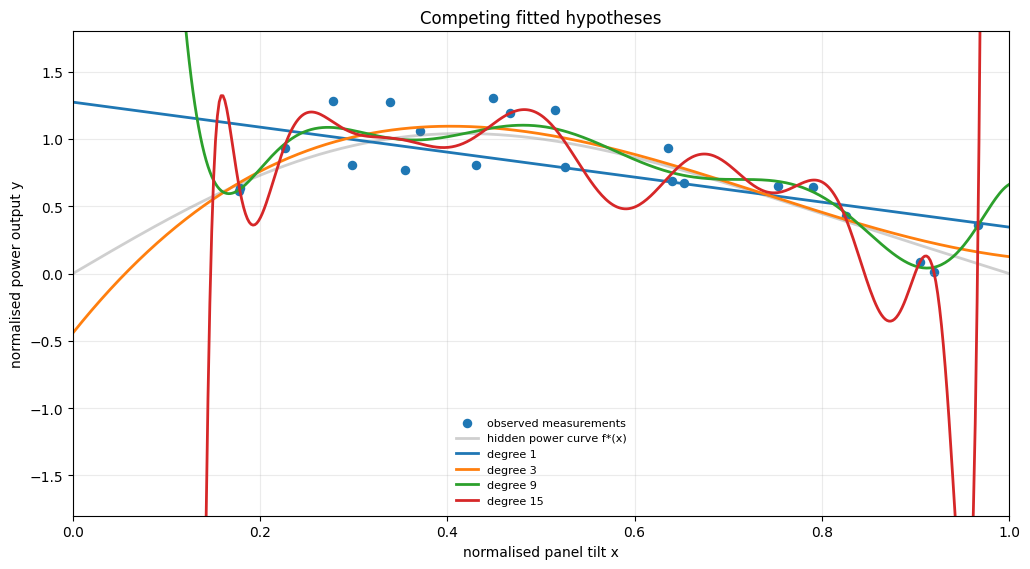

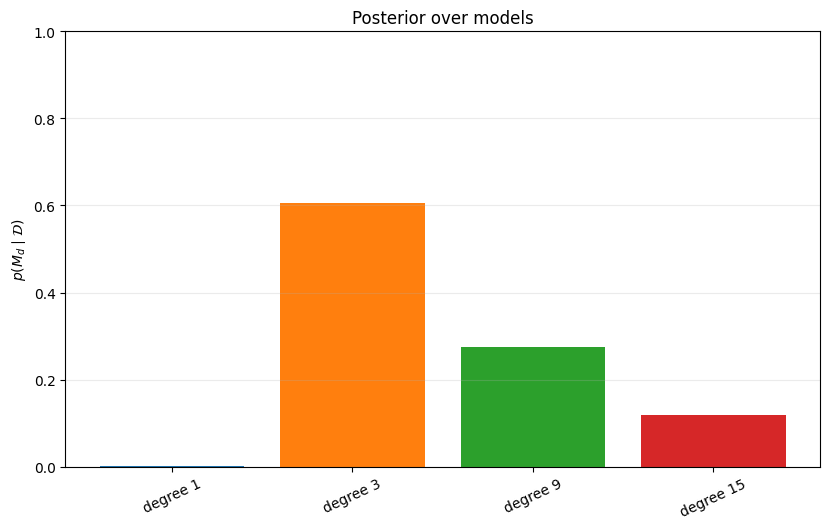

In [6]:
# Plot the candidate hypotheses and the posterior preference over them.
x_grid = data.make_test_grid(n_points=500)
colors = plt.get_cmap("tab10")

fig_curves, ax_curves = plt.subplots(figsize=(10.4, 5.8))
ax_curves.scatter(x_bayes, y_bayes, s=34, color="#1f77b4", label="observed measurements")
ax_curves.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
for idx, degree in enumerate(bayes_degrees):
    ax_curves.plot(
        x_grid,
        models.predict_polynomial(x_grid, bayes_coeffs[degree]),
        linewidth=2.0,
        color=colors(idx),
        label=f"degree {degree}",
    )
ax_curves.set_title("Competing fitted hypotheses")
ax_curves.set_xlabel("normalised panel tilt x")
ax_curves.set_ylabel("normalised power output y")
ax_curves.set_xlim(0.0, 1.0)
ax_curves.set_ylim(-1.8, 1.8)
ax_curves.grid(alpha=0.25)
ax_curves.legend(frameon=False, fontsize=8)
fig_curves.tight_layout()
show_fig(fig_curves)

labels = [f"degree {degree}" for degree in bayes_degrees]
bar_colors = [colors(idx) for idx, _ in enumerate(bayes_degrees)]
fig_post, ax_post = plt.subplots(figsize=(8.4, 5.4))
ax_post.bar(labels, bayes_posterior, color=bar_colors)
ax_post.set_title("Posterior over models")
ax_post.set_ylabel(r"$p(M_d \mid \mathcal{D})$")
ax_post.set_ylim(0.0, 1.0)
ax_post.tick_params(axis="x", rotation=25)
ax_post.grid(axis="y", alpha=0.25)
fig_post.tight_layout()
show_fig(fig_post)


**Inspect and repack**

- Inspect: compare the fitted curves with the posterior bar chart. Which degree looks visually flexible, and which degree receives the most posterior probability?
- Explain the posterior preference as prior plausibility times prior predictive evidence, not just as lowest training error.


**Diagnose**

Read the table from left to right. The prior gives each degree an initial share of plausibility. The evidence asks how much probability that degree assigned to datasets like $\mathcal{D}$ after averaging over its prior for $\theta$. Multiplying those two quantities and normalising gives the posterior over degrees.

The `plug_in_log_likelihood` column is a useful contrast: it scores the curve after the best-fitting $\theta$ has been chosen. The evidence columns ask how plausible the model class was before that choice. `evidence_quadratic` reflects data fit under the prior predictive covariance, while `evidence_logdet` reflects the volume of outcomes the model class spread probability over.

Reflection prompts:

- Which degree had the best fitted curve, and did it also receive the strongest evidence?
- Where did the prior over model classes matter most?
- What would you expect to happen if the observation story used a larger $\sigma$?


<br>

## 5. Evidence Depends on Prior Scale

Changing the prior scale changes what each model class expected before seeing data.


The prior scale $\tau$ controls how widely a model class spreads probability mass over functions before seeing the data. That makes evidence sensitive to a modelling judgement, not just to curve flexibility.

**Predict before running:** for very small $\tau$, which degrees should be too constrained to explain the data? For very large $\tau$, which degrees should spread probability over too many extreme datasets? Choose one `tau` value you expect to favour each degree, then compare with the table.

Read the next table as a stress test of the prior story. Very small $\tau$ says most plausible functions are tightly constrained. Very large $\tau$ says extreme functions were also plausible. Which scale makes the observed panel dataset $\mathcal{D}$ look most typical for each degree?


In [7]:
# Sweep the prior scale to see how evidence changes.
tau_values = (0.10, 0.30, 1.00, 3.00)
tau_rows = []

for tau_value in tau_values:
    evidence_by_degree = []
    for degree in bayes_degrees:
        Phi = models.polynomial_features(x_bayes, degree=degree)
        prior_cov = tau_value**2 * np.eye(degree + 1)
        log_evidence, _, _, _ = log_marginal_likelihood_components(
            Phi, y_bayes, sigma=bayes_sigma, prior_cov=prior_cov
        )
        evidence_by_degree.append(log_evidence)
        tau_rows.append(
            {
                "tau": tau_value,
                "degree": degree,
                "log_evidence": log_evidence,
            }
        )
    best_degree = bayes_degrees[int(np.argmax(evidence_by_degree))]
    tau_rows.append({"tau": tau_value, "degree": "best", "log_evidence": f"degree {best_degree}"})

print_rows(tau_rows, digits=4, title="Evidence sensitivity to the prior scale")

Evidence sensitivity to the prior scale
01. tau=0.1000, degree=1, log_evidence=-45.7023
02. tau=0.1000, degree=3, log_evidence=-42.8819
03. tau=0.1000, degree=9, log_evidence=-38.1557
04. tau=0.1000, degree=15, log_evidence=-37.5896
05. tau=0.1000, degree=best, log_evidence=degree 15
06. tau=0.3000, degree=1, log_evidence=-17.8564
07. tau=0.3000, degree=3, log_evidence=-10.3533
08. tau=0.3000, degree=9, log_evidence=-8.2282
09. tau=0.3000, degree=15, log_evidence=-8.4516
10. tau=0.3000, degree=best, log_evidence=degree 9
11. tau=1.0000, degree=1, log_evidence=-11.0298
12. tau=1.0000, degree=3, log_evidence=-4.2114
13. tau=1.0000, degree=9, log_evidence=-4.8438
14. tau=1.0000, degree=15, log_evidence=-4.5912
15. tau=1.0000, degree=best, log_evidence=degree 3
16. tau=3.0000, degree=1, log_evidence=-12.1440
17. tau=3.0000, degree=3, log_evidence=-5.3256
18. tau=3.0000, degree=9, log_evidence=-6.1936
19. tau=3.0000, degree=15, log_evidence=-6.9878
20. tau=3.0000, degree=best, log_evidence=

**Inspect and repack**

- Inspect: for each `tau`, mark the degree with the largest log evidence. Does changing the prior scale mostly shift scores, change the ranking, or both?
- Describe `tau` as a claim about which functions were plausible before seeing $\mathcal{D}$.


<br>

## 6. Priors as Preferences Over Functions

A parameter prior becomes a preference over possible curves.


The prior was written over $\theta$, but we usually reason about curves. Sampling from the prior is a quick way to see what the model class believed before seeing $\mathcal{D}$.

For the model-evidence example above, we used a proper Gaussian prior on all parameters:

$$
\theta \sim \mathcal{N}(0,\tau^2 I).
$$

Small $\tau$ keeps most coefficients near zero. Large $\tau$ permits larger coefficients. In polynomial regression, that can mean rapidly changing power-output functions, especially near the edges of the tilt range.

**Predict before running:** before looking at the prior samples, decide which panel should assign more prior probability to wild edge behaviour. Then use the observed tilt-setting rug marks to ask whether that behaviour is constrained by data or only by the prior.

The induced function prior has covariance

$$
\operatorname{cov}(f(x),f(x')) = \phi(x)^\top\Sigma_0\phi(x').
$$

When $\Sigma_0=\tau^2I$,

$$
\operatorname{cov}(f(x),f(x')) = \tau^2\phi(x)^\top\phi(x').
$$

This covariance depends on the feature map and scaling. Raw monomials, centred polynomials, orthogonal features, and Fourier features would all imply different beliefs about functions even with the same numerical $\tau$.

Notebook 03 used a ridge/MAP convention where the intercept was left unpenalised and the remaining parameters had Gaussian priors. That convention is useful for fitting; model evidence needs a proper prior or an explicit limiting argument.


In [8]:
# Sample theta values from two priors and look at the induced functions.
prior_degree = 9
small_tau = 0.20
large_tau = 1.50
n_prior_samples = 10
prior_seed = 18

rng = np.random.default_rng(prior_seed)
x_prior_grid = data.make_test_grid(n_points=500)
small_coeff_samples = rng.normal(scale=small_tau, size=(n_prior_samples, prior_degree + 1))
large_coeff_samples = rng.normal(scale=large_tau, size=(n_prior_samples, prior_degree + 1))

print_rows(
    [
        {"prior": "small_tau", "tau": small_tau, "first_sample_norm": np.linalg.norm(small_coeff_samples[0])},
        {"prior": "large_tau", "tau": large_tau, "first_sample_norm": np.linalg.norm(large_coeff_samples[0])},
    ],
    digits=4,
    title="Prior scales before seeing data",
)


Prior scales before seeing data
01. prior=small_tau, tau=0.2000, first_sample_norm=0.8749
02. prior=large_tau, tau=1.5000, first_sample_norm=2.8337


In [ ]:
# Visualise the functions implied by those sampled theta values.
prior_views = [
    (f"Small prior scale tau = {small_tau}", small_coeff_samples, "#4c78a8", 0.45),
    (f"Large prior scale tau = {large_tau}", large_coeff_samples, "#e15759", 0.38),
]

for title, coeff_samples, color, alpha in prior_views:
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    for coeffs in coeff_samples:
        ax.plot(x_prior_grid, models.predict_polynomial(x_prior_grid, coeffs), color=color, alpha=alpha, linewidth=1.2)
    ax.plot(x_prior_grid, data.true_function(x_prior_grid), color="#777777", alpha=0.35, linewidth=2.0)
    ax.vlines(x_like_train, -3.0, -2.85, color="#222222", alpha=0.35, linewidth=0.8, label="observed tilt settings")
    ax.set_title(title)
    ax.set_xlabel("normalised panel tilt x")
    ax.set_ylabel("sampled function")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-3.0, 3.0)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)


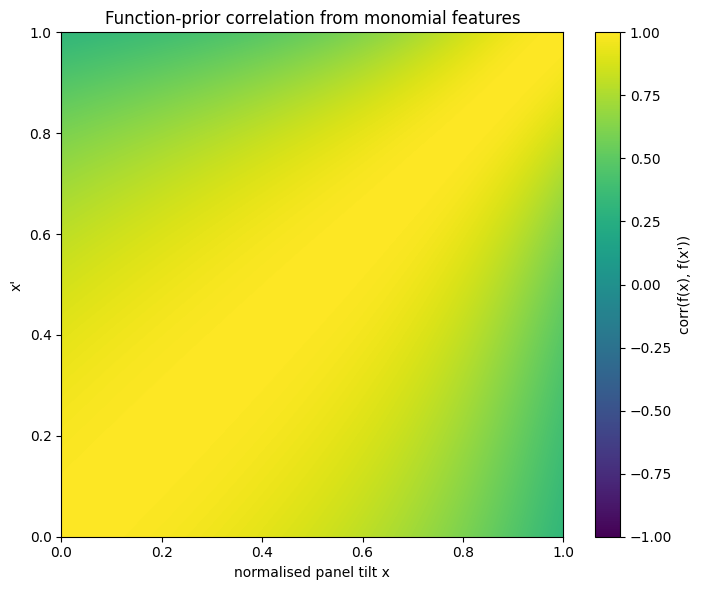

In [10]:
# Visualise the covariance function induced by the raw monomial prior.
Phi_prior_grid = models.polynomial_features(x_prior_grid, degree=prior_degree)
prior_covariance = small_tau**2 * (Phi_prior_grid @ Phi_prior_grid.T)
prior_correlation = prior_covariance / np.sqrt(np.outer(np.diag(prior_covariance), np.diag(prior_covariance)))

fig, ax = plt.subplots(figsize=(7.2, 6.0))
image = ax.imshow(
    prior_correlation,
    origin="lower",
    extent=[0.0, 1.0, 0.0, 1.0],
    aspect="auto",
    cmap="viridis",
    vmin=-1.0,
    vmax=1.0,
)
ax.set_title("Function-prior correlation from monomial features")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("x'")
fig.colorbar(image, ax=ax, label="corr(f(x), f(x'))")
fig.tight_layout()
show_fig(fig)


**Inspect and repack**

- Inspect: compare the sampled functions with the covariance heatmap. Which parts of the tilt range tend to move together under this prior?
- State the prior as a belief over curves, not only as a distribution over coefficients.


**Diagnose**

The prior is visible in function space. Small parameter scales produce calmer prior samples. Larger scales permit more volatile curves before any data are observed.

The observed tilt-setting rug marks are a reminder from the data-space notebooks: prior behaviour between or beyond measurements is not evidence-constrained yet. It is a modelling commitment.

The covariance heatmap shows the same idea without sampling. Inputs with high prior correlation tend to move together across sampled functions. Because this covariance came from raw monomial features, it also reveals a property of that parameterisation.

Connect this back to regularisation. A penalty on parameter size can be read as prior belief about which $\theta$ values were plausible before $\mathcal{D}$. The scientific question is whether the induced prior over functions matches the behaviour you would have expected before measuring anything.


<br>

## 7. MAP and Ridge From a Balance Question

Ridge is MAP when Gaussian residuals and Gaussian coefficient priors are assumed.


Suppose residuals are judged with power-sensor scale $\sigma$, and the prior says non-intercept coefficients usually have scale $\tau$. The posterior balances fit to $\mathcal{D}$ against prior plausibility.

With Gaussian measurement noise,

$$
p(\mathcal{D}\mid\theta,\sigma)\propto
\exp\left(-\frac{1}{2\sigma^2}\lVert\Phi\theta-y\rVert_2^2\right),
$$

and a Gaussian prior on penalised parameters,

$$
p(\theta\mid\tau)\propto
\exp\left(-\frac{1}{2\tau^2}\lVert R\theta\rVert_2^2\right).
$$

The negative log posterior is proportional to

$$
\frac{1}{\sigma^2}\lVert\Phi\theta-y\rVert_2^2+
\frac{1}{\tau^2}\lVert R\theta\rVert_2^2.
$$

Multiplying by $\sigma^2$ gives the ridge form

$$
\lVert\Phi\theta-y\rVert_2^2+\lambda\lVert R\theta\rVert_2^2,
\qquad \lambda=\frac{\sigma^2}{\tau^2}.
$$

So ridge is MAP under this Gaussian likelihood and prior. Change `map_sigma` or `map_tau`, predict which pressure dominates, then rerun.


In [ ]:
# Compare the ridge solution with the MAP formula.
map_degree = 9
map_sigma = 0.20
map_tau = 0.30
map_lambda = (map_sigma**2) / (map_tau**2)

Phi_map = models.polynomial_features(x_like_train, degree=map_degree)
R = np.eye(map_degree + 1)
R[0, 0] = 0.0

map_system = Phi_map.T @ Phi_map + map_lambda * R
map_rhs = Phi_map.T @ y_like_train
map_coeffs = np.linalg.solve(map_system, map_rhs)
ridge_coeffs = models.fit_polynomial_ridge_map(
    x_like_train,
    y_like_train,
    degree=map_degree,
    lambda_reg=map_lambda,
)

print_rows(
    [
        {"quantity": "sigma", "value": map_sigma},
        {"quantity": "tau", "value": map_tau},
        {"quantity": "lambda = sigma^2 / tau^2", "value": map_lambda},
        {"quantity": "max_abs_difference", "value": np.max(np.abs(map_coeffs - ridge_coeffs))},
    ],
    digits=6,
    title="Ridge as a MAP estimate",
)

**Inspect and repack**

- Inspect: the `max_abs_difference` should be near numerical precision. That checks whether the MAP formula and ridge helper selected the same coefficients for this `lambda`.
- Explain `map_lambda = sigma^2 / tau^2` as the balance between measurement tolerance and prior shrinkage.


<br>

## 8. Posterior Uncertainty: Where Has Data Constrained the Function?

Posterior uncertainty shows where data constrain the function under the chosen assumptions.


A MAP estimate gives one $\theta$. The posterior distribution keeps the remaining uncertainty over $\theta$ after conditioning on the chosen degree, feature map, noise scale, prior scale, intercept convention, and $\mathcal{D}$.

For the ridge convention with unpenalised intercept, define the prior precision selector

$$
P_0=\operatorname{diag}(0,1,1,\ldots,1).
$$

The posterior covariance and mean are

$$
\Sigma_N = \left(\sigma^{-2}\Phi^\top\Phi + \tau^{-2}P_0\right)^{-1},
\qquad
\mu_N = \sigma^{-2}\Sigma_N\Phi^\top y.
$$

For new tilt settings with feature matrix $\Phi_*$,

$$
\operatorname{cov}(f_*\mid\mathcal{D}) = \Phi_*\Sigma_N\Phi_*^\top.
$$

For a single new tilt setting $x_*$,

$$
\operatorname{var}(f_*\mid\mathcal{D})
= \phi(x_*)^\top\Sigma_N\phi(x_*).
$$

For a future noisy solar-power reading, add $\sigma^2$.

**Predict before running:** where should the latent uncertainty band be widest: near measured tilt settings, between measured tilt settings, or at the edges? Change one of `uncertainty_tau`, `uncertainty_sigma`, or the probe locations at a time, then rerun both posterior cells below.

The plot asks where the panel data and prior have pinned down the latent response function, and where several functions are still plausible.


In [ ]:
# Visualise posterior uncertainty for the latent function.
uncertainty_degree = 9
uncertainty_sigma = 0.20
uncertainty_tau = 0.30
posterior_sample_seed = 44

Phi_train = models.polynomial_features(x_like_train, degree=uncertainty_degree)
Phi_grid = models.polynomial_features(x_grid, degree=uncertainty_degree)
prior_precision = np.zeros((uncertainty_degree + 1, uncertainty_degree + 1))
prior_precision[1:, 1:] = np.eye(uncertainty_degree)
posterior_precision = (Phi_train.T @ Phi_train) / uncertainty_sigma**2 + prior_precision / uncertainty_tau**2
posterior_cov = np.linalg.inv(posterior_precision)
posterior_mean = (posterior_cov @ Phi_train.T @ y_like_train) / uncertainty_sigma**2

latent_mean = Phi_grid @ posterior_mean
latent_cov = Phi_grid @ posterior_cov @ Phi_grid.T
latent_var = np.diag(latent_cov)
latent_std = np.sqrt(np.maximum(latent_var, 0.0))
obs_std = np.sqrt(latent_var + uncertainty_sigma**2)

rng = np.random.default_rng(posterior_sample_seed)
posterior_theta_samples = rng.multivariate_normal(
    mean=posterior_mean,
    cov=posterior_cov,
    size=8,
    method="svd",
)
posterior_function_samples = posterior_theta_samples @ Phi_grid.T

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for sample in posterior_function_samples:
    ax.plot(x_grid, sample, color="#2ca02c", alpha=0.25, linewidth=1.0)
ax.scatter(x_like_train, y_like_train, s=34, color="#1f77b4", label="training measurements")
ax.vlines(x_like_train, -2.4, -2.24, color="#222222", alpha=0.35, linewidth=0.8, label="observed tilt settings")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
ax.plot(x_grid, latent_mean, color="#2ca02c", linewidth=2.2, label="posterior mean")
ax.fill_between(x_grid, latent_mean - 2 * latent_std, latent_mean + 2 * latent_std, color="#2ca02c", alpha=0.18, label="latent +/- 2 std")
ax.fill_between(x_grid, latent_mean - 2 * obs_std, latent_mean + 2 * obs_std, color="#4c78a8", alpha=0.10, label="future observation +/- 2 std")
ax.set_title("Posterior uncertainty under Bayesian linear regression")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("normalised power output y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.4, 2.4)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
show_fig(fig)


In [ ]:
# Probe posterior uncertainty at a few input locations.
probe_x = np.array([0.05, 0.20, 0.50, 0.80, 0.95])
Phi_probe = models.polynomial_features(probe_x, degree=uncertainty_degree)
probe_latent_var = np.diag(Phi_probe @ posterior_cov @ Phi_probe.T)
probe_latent_std = np.sqrt(np.maximum(probe_latent_var, 0.0))
probe_obs_std = np.sqrt(probe_latent_var + uncertainty_sigma**2)
nearest_train_distance = np.min(np.abs(probe_x[:, None] - x_like_train[None, :]), axis=1)

probe_rows = []
for x_value, distance, latent_std_value, obs_std_value in zip(
    probe_x,
    nearest_train_distance,
    probe_latent_std,
    probe_obs_std,
):
    probe_rows.append(
        {
            "x_probe": x_value,
            "nearest_train_distance": distance,
            "latent_std": latent_std_value,
            "future_observation_std": obs_std_value,
        }
    )

print_rows(probe_rows, digits=4, title="Posterior uncertainty probes")

**Inspect and repack**

- Inspect: compare the widest latent band with the largest `latent_std` rows. Are they near sparse data locations, near the edges, or both?
- Say "uncertainty under this model and these assumptions," not simply "the uncertainty."


The uncertainty band and the probe table reflect the assumptions we chose: polynomial features, Gaussian noise, Gaussian prior scale, the intercept convention, and the observed measurement locations. They are conditional uncertainty inside this model. They leave open uncertainty over the feature map, polynomial degree, noise scale, prior scale, and whether the solar-power measurement story is scientifically adequate.

In workshop-frame language, $\mathcal{H}$ is the polynomial feature map and degree, $\mathcal{D}$ is the finite observed sample, and $\mathcal{O}$ is the likelihood-prior-posterior machinery. The posterior predictive summary is not a universal uncertainty statement; it is the selected probabilistic summary inside those choices.

The posterior parameter samples give the same message in function space. With a proper Gaussian prior over all parameters, a finite-feature Bayesian linear model is also the parameter-space view of a Gaussian process with kernel $k(x,x')=\phi(x)^\top\Sigma_0\phi(x')$. The unpenalised-intercept convention we used for MAP is a useful modelling choice; evidence calculations and kernel priors need a proper prior or an explicit limiting argument.


### Solo or group reflection: translate the belief
Pick one probabilistic object from this notebook: likelihood, prior, evidence, MAP estimate, or posterior band. Translate it into one sentence about the modelling situation. If that sentence sounds implausible for your own problem, the formula probably needs to change.


<br>

## 9. Final Diagnostic Frame

Probabilistic model behaviour should be traced back to assumptions, data, and hypothesis space.


When a fitted model behaves strangely, treat the behaviour as evidence about the assumptions.

- $\mathcal{H}$: what hypotheses were possible?
- $\Theta$: which parameter values could select them?
- $\mathcal{D}$: what evidence constrained them?
- $\mathcal{O}$: what likelihood, loss, prior, penalty, evidence calculation, optimizer, or summary rule was used?

Underfitting, overfitting, edge extrapolation, excessive smoothness, and overconfident uncertainty can have different causes. Ask which assumption would need to change for the behaviour to become unsurprising.

**Probabilistic glossary**

| Term | Short meaning |
|---|---|
| Likelihood | Compatibility of $\mathcal{D}$ with $\theta$ under a measurement story |
| Prior | Probability before this dataset, over parameters, functions, or classes |
| Posterior | Updated probability after likelihood and prior combine |
| Evidence | Prior predictive probability of the data under a model class |
| MAP | Posterior mode |
| Prior predictive | Possible data or functions before conditioning on $\mathcal{D}$ |
| Posterior predictive | Latent functions or future observations after conditioning on $\mathcal{D}$ |

Final check: which conclusion depends most on the measurement story, which on the prior, and which on the measured tilt settings?


<br>

## 10. Bridge to Later Workshops

The same diagnostic frame carries into richer models and learned representations.


Workshop 1 used a friendly case:

$$
h_\theta(x)=\theta^\top\phi(x), \qquad \theta\in\Theta, \qquad h_\theta\in\mathcal{H}.
$$

The human chose the feature map, and the optimizer chose $\theta$. Because the model is linear in $\theta$, least squares, ridge, and Bayesian linear regression had direct formulas.

Later workshops can relax those conveniences. Neural networks can learn parts of the feature map. Objectives are usually optimized iteratively. Data may be high dimensional, biased, incomplete, or expensive to label. Uncertainty may be approximate or implicit.

The diagnostic habit stays the same:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow \text{model behaviour}.
$$

Keep asking: what hypotheses were possible, what evidence was available, what selected or summarised the model, and what would make the behaviour defensible for the task?


<br>

## 11. References

These references support the likelihood, prior, evidence, MAP, and posterior-uncertainty ideas used here.


References for likelihood, Bayesian linear regression, evidence, Bayes factors, and Gaussian-process connections.

- Bishop, C. M. (2006). [*Pattern Recognition and Machine Learning*](https://link.springer.com/book/9780387310732). Gaussian likelihoods, MAP estimation, Bayesian linear regression, and predictive uncertainty.
- Lindley, D. V., & Smith, A. F. M. (1972). [*Bayes Estimates for the Linear Model*](https://academic.oup.com/jrsssb/issue/34/1), *Journal of the Royal Statistical Society: Series B*, 34(1), 1-18. Classical Bayesian linear-model conjugacy and shrinkage.
- MacKay, D. J. C. (1992). [*Bayesian Interpolation*](https://direct.mit.edu/neco/article/4/3/415/5639/Bayesian-Interpolation), *Neural Computation*, 4(3), 415-447. Model evidence, Occam factors, prior scale, and Bayesian interpolation.
- Kass, R. E., & Raftery, A. E. (1995). [*Bayes Factors*](https://www.tandfonline.com/doi/abs/10.1080/01621459.1995.10476572), *Journal of the American Statistical Association*, 90(430), 773-795. Bayesian model comparison and the interpretation of evidence.
- Rasmussen, C. E., & Williams, C. K. I. (2006). [*Gaussian Processes for Machine Learning*](https://mitpress.mit.edu/9780262182539/gaussian-processes-for-machine-learning/). Relationship between Bayesian linear models, kernels, Gaussian processes, and function-space uncertainty.
